# Generating Random Channel Matrices from a DeepMIMO Scenario

This notebook demonstrates how to use **NeoRadium**'s [DeepMimoData.getChanGen](https://ail-wireless.pages.interdigital.com/neoradium/source/API/DeepMIMO.html#neoradium.deepmimo.DeepMimoData.getChanGen) function to generate random channel matrices from a [DeepMIMO](https://www.deepmimo.net) scenario.

The notebook first opens a DeepMIMO scenario and displays a map of the simulation area. It then creates channel generators for two examples:

1. **SISO channel generation with default settings:** creates 1,000 single-input single-output channel matrices using the default [getChanGen](https://ail-wireless.pages.interdigital.com/neoradium/source/API/DeepMIMO.html#neoradium.deepmimo.DeepMimoData.getChanGen) settings.
2. **Filtered MIMO channel generation:** creates 1,000 multiple-input multiple-output channel matrices using additional filtering criteria, including LOS/NLOS condition, UE distance, UE position, and custom TX/RX antenna configurations.

The generated channel matrices are collected into NumPy arrays using `np.stack`, and the resulting array shapes are printed to show the dimensions of the generated channel datasets.

### Notes

- The user may need to update the `dataFolder` variable based on the location of the DeepMIMO scenario files on their system.
- The [getChanGen](https://ail-wireless.pages.interdigital.com/neoradium/source/API/DeepMIMO.html#neoradium.deepmimo.DeepMimoData.getChanGen) function returns a channel generator. The channel matrices are generated when the generator is iterated over.
- The selected UE points can be visualized on the DeepMIMO map using [drawMap](https://ail-wireless.pages.interdigital.com/neoradium/source/API/DeepMIMO.html#neoradium.deepmimo.DeepMimoData.drawMap).
- Points with total blockage are ignored by the channel generator.
- If the requested filtering criteria are too restrictive, the generator may return fewer channels than requested, or no channels at all.

In [1]:
import numpy as np
from neoradium import DeepMimoData, BandwidthPart, AntennaPanel


In [2]:
# Replace this with the folder on your system where the DeepMIMO scenarios are stored
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
deepMimoData = DeepMimoData("asu_campus_3p5")
deepMimoData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%



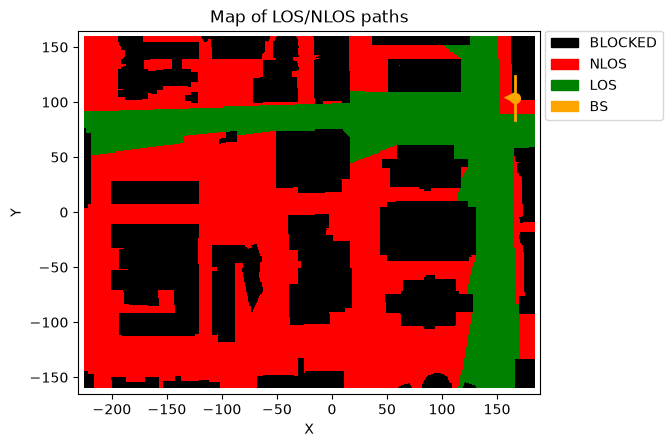

In [3]:
# Draw a map of the scenario showing line-of-sight (LOS) vs non-line-of-sight (NLOS) communication
# between the UEs and the base station.
ax = deepMimoData.drawMap("LOS-NLOS")   # Other map options include "1stPathDelays" and "1stPathPowers"
deepMimoData.drawBsPanel(ax, 180)       # TX antenna with a 180-degree bearing angle

## Generate 1,000 SISO Channels with Default Settings

In this example, `getChanGen` is used to create a channel generator for 1,000 SISO channel matrices. Only the number of channels, the bandwidth part, and the random seed are specified, so the remaining parameters use their default values.

The selected UE points are shown on the DeepMIMO map, and the generated channel matrices are stacked into a single NumPy array.

Shape of 'allChannels': (1000, 14, 288, 1, 1)


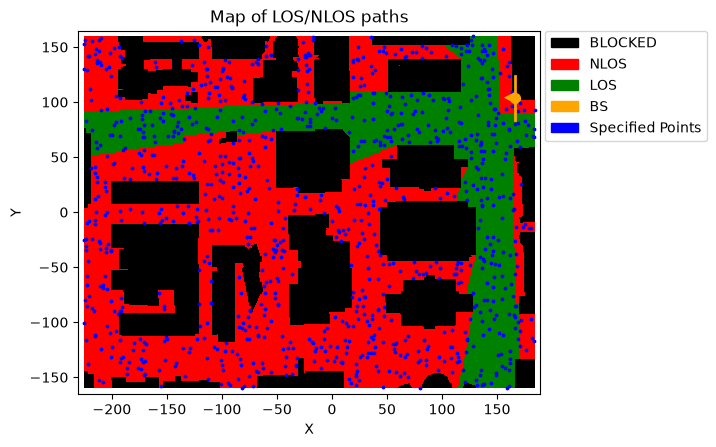

In [4]:
bwp = BandwidthPart(numRbs=24, spacing=15)                  # Create a BandwidthPart object
chanGen = deepMimoData.getChanGen(1000, bwp, seed=1234)     # Create a channel generator with default settings

ax = deepMimoData.drawMap("LOS-NLOS", chanGen.pointIdx)     # Draw the selected points on the map
deepMimoData.drawBsPanel(ax, 180)                           # TX antenna with a 180-degree bearing angle

allChannels = np.stack([chan for chan in chanGen])          # Create the channel matrices
print(f"Shape of 'allChannels': {allChannels.shape}")

## Generate 1,000 Filtered MIMO Channels

In this example, `getChanGen` is used with additional filtering and antenna-configuration parameters to generate MIMO channel matrices.

The selected points are restricted to non-line-of-sight locations within a specified distance range, position range. Custom TX and RX antenna panels are also used to create MIMO channels.

The notebook then displays the selected UE points on the map, checks whether any channels were generated, and stacks the generated channel matrices into a NumPy array.

Shape of 'allChannels': (1000, 14, 288, 4, 16)


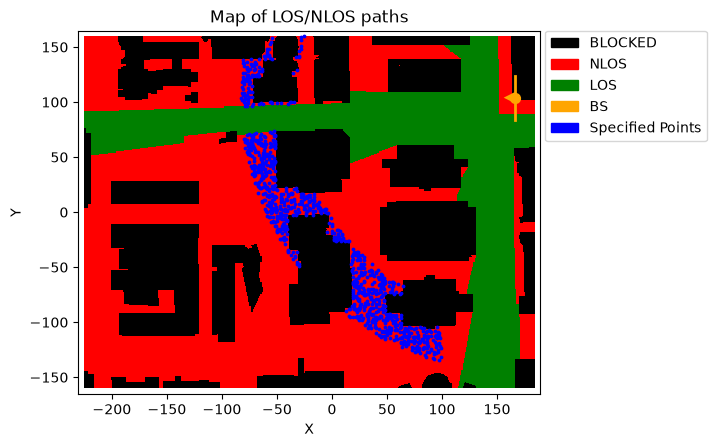

In [5]:
# Create 1000 MIMO channel matrices
chanGen = deepMimoData.getChanGen(1000, 
                                  bwp,                          # Bandwidth part  
                                  los = False,                  # Include only non-line-of-sight channels
                                  minDist = 200,                # Minimum distance to the base station, in meters
                                  maxDist = 250,                # Maximum distance to the base station, in meters
                                  maxX = 100,                   # Maximum x-coordinate, in meters
                                  ueSpeed = (10,20),            # Use random UE speed between 10 and 20 m/s
                                  ueDir = [0, 270],             # Use random UE direction: right or down
                                  txOrientation = [180,0,0],    # BS antenna facing the left side of the map
                                  txAntenna = AntennaPanel([2,4], polarization="x"),    # 16 TX antennas
                                  rxAntenna = AntennaPanel([1,2], polarization="x"),    # 4 RX antennas
                                  seed = 123)                   # Make the results reproducible
                                  

ax = deepMimoData.drawMap("LOS-NLOS", chanGen.pointIdx)         # Draw the selected points on the map
deepMimoData.drawBsPanel(ax, 180)                               # TX antenna with a 180-degree bearing angle

# Create the channel matrices
if len(chanGen) == 0:
    raise RuntimeError("No channels were generated. Try relaxing the filter criteria.")
allChannels = np.stack([chan for chan in chanGen])  
print(f"Shape of 'allChannels': {allChannels.shape}")